<a href="https://colab.research.google.com/github/carlocamilloni/Structural-Bioinformatics/blob/main/Notebooks/report_2_stat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Start by saving a copy of this **notebook** in your Google Drive.

# Probability distributions and free energies


---
Your name

In [1]:
from datetime import date

today = date.today()
print(today)

2026-06-06


## A. Sampling from a uniform discrete distribution (First Group)

**Exercise A1**: for M=2000 trials try to generate N=2000 random integer numbers between 1 and 20 and calculate their average and standard deviation. Plot one representative histogram, the histogram of the average and calculate its standard deviation.

**Exercise A2**: Calculate and plot the average and the standard deviation of the average for N integer numbers between 1 and 20 by keeping M=20 fixed and increasing the number N between 1 and 2000.

**Exercise A3**: Calculate and plot the average and the standard deviation of the average for N integer numbers between 1 and 20 by keeping N=20 fixed and increasing the number of trials M between 1 and 2000.

`What do you observe?`

## B. Sampling from a Gaussian distribution (First Group)


**Exercise B1**: for M=2000 trials try to generate N=2000 random numbers from a Gaussian centered in 10.5 with a standard deviation of 5.7663 and calculate their average and standard deviation. Plot one representative histogram, the histogram of the average and calculate its standard deviation.

**Exercise B2**: Calculate and plot the average and the standard deviation of the average for N real numbers from a Gaussian centered in 10.5 with a standard deviation of 5.7663 by keeping M=20 fixed and increasing the number N between 1 and 2000.

**Exercise B3**: Calculate and plot the average and the standard deviation of the average for N real numbers from a Gaussian centered in 10.5 with a standard deviation of 5.7663 by keeping N=20 fixed and increasing the number of trials M between 1 and 2000.

`What do you observe?`

## C. Sampling from a multimodal distribution (Second Group)

**Exercise C1**: for M=2000 trials try to generate N=2000 random numbers from a distribution made of one Gaussian centered in 4.8 with a standard deviation of 1 and another Gaussian centered in 16.2 with a standard deviation of 1 and calculate their average and standard deviation. Plot one representative histogram, the histogram of the average and calculate its standard deviation.

**Exercise C2**: Calculate and plot the average and the standard deviation of the average for N real numbers from a distribution made of one Gaussian centered in 4.8 with a standard deviation of 1 and another Gaussian centered in 16.2 with a standard deviation of 1 by keeping M=20 fixed and increasing the number N between 1 and 2000.

**Exercise C3**: Calculate and plot the average and the standard deviation of the average for N real numbers from a distribution made of one Gaussian centered in 4.8 with a standard deviation of 1 and another Gaussian centered in 16.2 with a standard deviation of 1 by keeping N=20 fixed and increasing the number of trials M between 1 and 2000.

`What do you observe?`

## Probabilities and free energies (Second Group)

First download the file with the data:

In [3]:
import pandas as pd
import requests
import gzip
from io import BytesIO

# URL of the raw gzipped CSV file on GitHub
gz_csv_url = "https://raw.githubusercontent.com/carlocamilloni/Structural-Bioinformatics/2a766bf808b5b881188b346e3203f21e1b1dd8de/Data/stats/multimodal_gaussian_samples.csv.gz"

# Download the gzipped content
response = requests.get(gz_csv_url)
response.raise_for_status() # Raise an exception for bad status codes

# Read the gzipped content from bytes
gzipped_file = BytesIO(response.content)

# Ungzip the content and read into a pandas DataFrame
with gzip.open(gzipped_file, 'rt') as f:
    df_samples = pd.read_csv(f)

# Display the first few rows of the DataFrame
display(df_samples.head())

,Dimension 1,Dimension 2
0,0.994441,0.969085
1,0.994445,0.994954
2,0.764301,1.033098
3,0.949795,1.033733
4,-0.448379,0.748629


In [4]:
df_samples

,Dimension 1,Dimension 2
0,0.994441,0.969085
1,0.994445,0.994954
2,0.764301,1.033098
3,0.949795,1.033733
4,-0.448379,0.748629
...,...,...
99995,0.366652,1.033294
99996,0.082973,-0.019144
99997,0.691425,1.121499
99998,0.094809,0.875461


Make 1D and 2D histograms to get an idea of the features in the data.

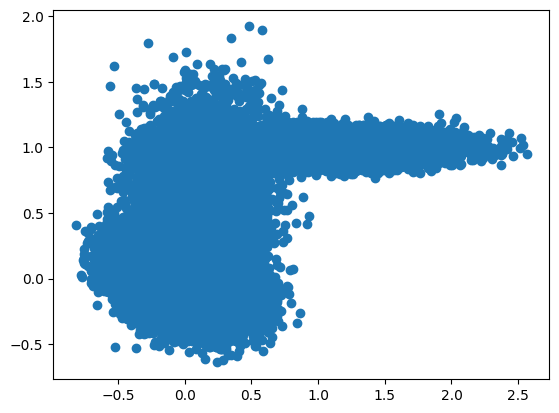

In [9]:
import matplotlib.pyplot as plt
plt.plot(df_samples["Dimension 1"], df_samples["Dimension 2"], 'o')

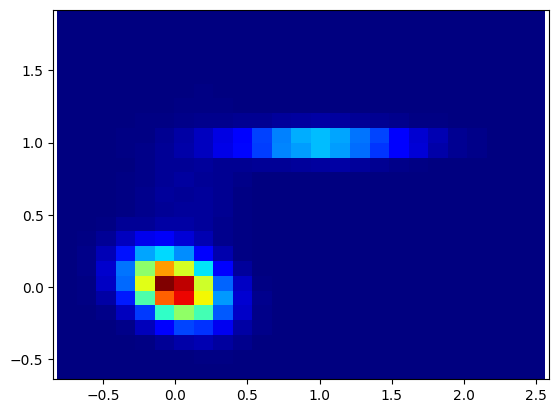

In [10]:
# Big bins
plt.hist2d(df_samples["Dimension 1"], df_samples["Dimension 2"], bins=(25, 25), cmap=plt.cm.jet)
plt.axis('equal')
plt.show()

Transform the histograms in Free Energy plots at ambient temperature

Define states in the data and calculate their free energy difference and their relative populations

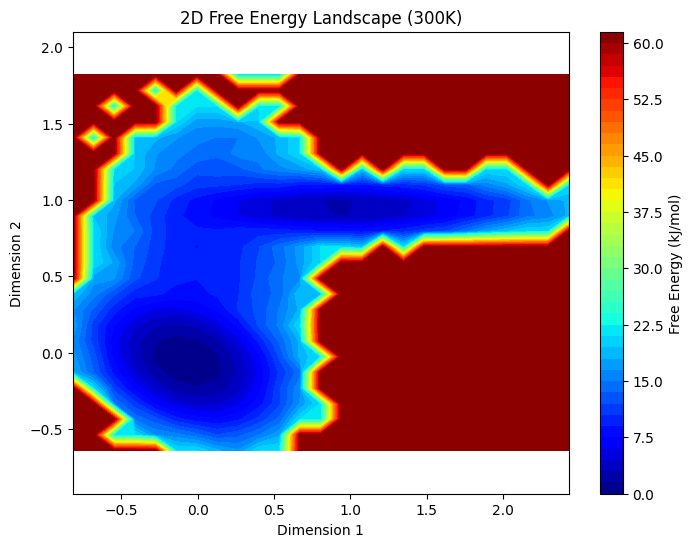

总样本数：100000.0
状态1 布居数：0.370 | 自由能：2.468 kJ/mol
状态2 布居数：0.630 | 自由能：1.143 kJ/mol
状态2 与 状态1 自由能差 ΔΔG：-1.324 kJ/mol


In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------
# 1. 基础参数（常温 300K）
# --------------------------
kBT = 2.479  # 单位：kJ/mol，玻尔兹曼常数×温度
bins = (25, 25)  # 与你原代码一致的bins

# --------------------------
# 2. 计算二维直方图（计数）
# --------------------------
# 提取二维数据
x = df_samples["Dimension 1"]
y = df_samples["Dimension 2"]

# 计算直方图计数（不绘图，纯数值计算）
counts, x_edges, y_edges = np.histogram2d(x, y, bins=bins)

# 总样本数
total_samples = np.sum(counts)

# --------------------------
# 3. 概率分布 → 自由能计算
# --------------------------
# 转概率（避免0计数导致ln无穷大，加极小值）
prob = counts / total_samples + 1e-12  

# 自由能计算（单位：kJ/mol）
free_energy = -kBT * np.log(prob)

# 归一化自由能：最低自由能设为0（最稳定状态为参考）
free_energy -= np.min(free_energy)

# --------------------------
# 4. 绘制二维自由能图
# --------------------------
plt.figure(figsize=(8, 6))
# 绘制自由能热力图
plt.contourf(x_edges[:-1], y_edges[:-1], free_energy.T, 
             cmap=plt.cm.jet, levels=50)
plt.colorbar(label='Free Energy (kJ/mol)')
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.title("2D Free Energy Landscape (300K)")
plt.axis('equal')
plt.show()

# --------------------------
# 5. 【关键】定义两个状态 + 计算布居数/自由能差
# --------------------------
# 手动定义状态（根据你的自由能图低谷区域修改阈值！）
# 示例：按 Dimension 1 划分两个状态
STATE1_THRESHOLD = 0  # 状态1：Dim1 < 0
STATE2_THRESHOLD = 0  # 状态2：Dim1 > 0

# 筛选两个状态的样本
state1 = df_samples[df_samples["Dimension 1"] < STATE1_THRESHOLD]
state2 = df_samples[df_samples["Dimension 1"] > STATE2_THRESHOLD]

# 计算布居数（Population）
pop1 = len(state1) / total_samples
pop2 = len(state2) / total_samples

# 计算状态自由能（以最低自由能为0）
G1 = -kBT * np.log(pop1)
G2 = -kBT * np.log(pop2)
delta_G = G2 - G1  # 自由能差：State2 → State1

# --------------------------
# 6. 打印结果
# --------------------------
print("="*50)
print(f"总样本数：{total_samples}")
print(f"状态1 布居数：{pop1:.3f} | 自由能：{G1:.3f} kJ/mol")
print(f"状态2 布居数：{pop2:.3f} | 自由能：{G2:.3f} kJ/mol")
print(f"状态2 与 状态1 自由能差 ΔΔG：{delta_G:.3f} kJ/mol")
print("="*50)

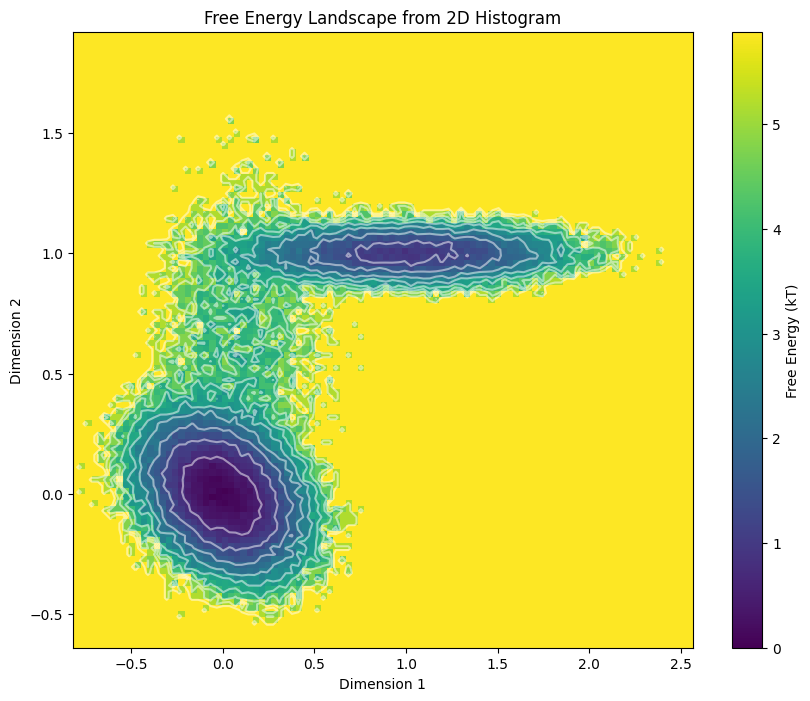

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def histogram_to_free_energy(x, y, bins=100, kT=1.0):
    """
    将二维散点数据转换为自由能面。
    
    公式: F = -kT * log(P), 其中P是直方图归一化后的概率密度。
    
    Parameters
    ----------
    x, y : array-like, 输入数据
    bins : int or tuple, 网格数
    kT : float, 温度能量因子
    
    Returns
    -------
    F : 2D array, 自由能面(相对于全局最小值)
    extent : tuple, 绘图范围(xmin,xmax,ymin,ymax)
    """
    # 构建2D直方图并归一化为概率密度
    hist, xedges, yedges = np.histogram2d(x, y, bins=bins, density=True)
    
    # 处理空网格: 将零概率替换为最小的非零概率值
    min_nonzero = hist[hist > 0].min()
    hist[hist == 0] = min_nonzero
    
    # Boltzmann反演: F = -kT ln(P)
    F = -kT * np.log(hist)
    
    # 将最小值设为0
    F = F - F.min()
    
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    return F, extent

# 应用该函数
F_surface, extent = histogram_to_free_energy(
    df_samples['Dimension 1'], 
    df_samples['Dimension 2'], 
    bins=100, 
    kT=1.0
)

# 绘制自由能景观
plt.figure(figsize=(10, 8))
plt.imshow(F_surface.T, origin='lower', extent=extent, aspect='auto', cmap='viridis')
plt.colorbar(label='Free Energy (kT)')
plt.title('Free Energy Landscape from 2D Histogram')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.contour(F_surface.T, levels=10, extent=extent, colors='white', alpha=0.5)
plt.show()

In [6]:
from scipy import ndimage
from scipy.optimize import minimize

def identify_states_from_fes(F_surface, extent, kT=1.0):
    """
    从自由能面识别状态区域并计算自由能差。
    
    思路：自由能面上的每个局部极小值对应一个热力学状态。
    通过图像处理找到所有局部极小值，根据能量槽确定状态边界。
    """
    # 找到局部极小值
    min_mask = (F_surface == ndimage.minimum_filter(F_surface, size=5))
    min_coords = np.argwhere(min_mask)
    
    # 获取极小值点的自由能值
    min_values = [F_surface[tuple(coord)] for coord in min_coords]
    
    # 对状态按自由能排序，最低自由能状态为参考状态
    sorted_indices = np.argsort(min_values)
    
    # 计算自由能差 (相对于最低自由能状态)
    fes_differences = [(min_values[i] - min_values[sorted_indices[0]]) * kT 
                       for i in sorted_indices]
    
    # 计算相对布居比
    populations = np.exp(-np.array(fes_differences))
    relative_populations = populations / populations.sum()
    
    return min_coords, min_values, fes_differences, relative_populations

# 应用该函数
states_coords, states_F, fes_diffs, rel_pops = identify_states_from_fes(F_surface, extent)
for i, (coords, fe_diff, rel_pop) in enumerate(zip(states_coords, fes_diffs, rel_pops)):
    print(f"State {i+1}: F_diff = {fe_diff:.2f} kT, Relative Population = {rel_pop:.3%}")

State 1: F_diff = 0.00 kT, Relative Population = 5.878%
State 2: F_diff = 0.80 kT, Relative Population = 2.636%
State 3: F_diff = 0.90 kT, Relative Population = 2.390%
State 4: F_diff = 1.42 kT, Relative Population = 1.424%
State 5: F_diff = 2.79 kT, Relative Population = 0.360%
State 6: F_diff = 2.79 kT, Relative Population = 0.360%
State 7: F_diff = 2.84 kT, Relative Population = 0.344%
State 8: F_diff = 3.18 kT, Relative Population = 0.246%
State 9: F_diff = 3.18 kT, Relative Population = 0.246%
State 10: F_diff = 3.24 kT, Relative Population = 0.229%
State 11: F_diff = 3.24 kT, Relative Population = 0.229%
State 12: F_diff = 3.24 kT, Relative Population = 0.229%
State 13: F_diff = 3.32 kT, Relative Population = 0.213%
State 14: F_diff = 3.32 kT, Relative Population = 0.213%
State 15: F_diff = 3.40 kT, Relative Population = 0.196%
State 16: F_diff = 3.40 kT, Relative Population = 0.196%
State 17: F_diff = 3.49 kT, Relative Population = 0.180%
State 18: F_diff = 3.69 kT, Relative Pop

In [7]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

def cluster_states_by_dbscan(df, eps=0.2, min_samples=10):
    """
    使用DBSCAN密度聚类在原始数据点空间识别离散状态。
    
    DBSCAN参数:
    - eps: 邻域半径,决定了两个点被视为"邻居"的尺度
    - min_samples: 聚类所需的最小点数
    """
    X = df[['Dimension 1', 'Dimension 2']].values
    
    # 可选：标准化数据(DBSCAN对特征尺度敏感)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # 执行聚类
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X_scaled)
    
    # 计算各聚类的大小和概率
    unique_labels = set(labels)
    cluster_stats = []
    
    for label in unique_labels:
        if label == -1:  # -1表示噪声点，不视为状态
            continue
        mask = labels == label
        cluster_points = X[mask]
        cluster_prob = mask.sum() / len(X)
        cluster_stats.append({
            'label': label,
            'center': cluster_points.mean(axis=0),
            'size': mask.sum(),
            'probability': cluster_prob
        })
    
    # 计算自由能差 (相对于概率最大的聚类)
    max_prob = max(c['probability'] for c in cluster_stats)
    for stats in cluster_stats:
        stats['free_energy_diff'] = -np.log(stats['probability'] / max_prob)
        stats['population'] = stats['probability']
    
    return labels, cluster_stats

# 应用聚类
labels, cluster_stats = cluster_states_by_dbscan(df_samples, eps=0.3, min_samples=100)
for stats in cluster_stats:
    print(f"Cluster {stats['label']}: Center = {stats['center']}, "
          f"Probability = {stats['probability']:.3f}, "
          f"Free Energy Diff = {stats['free_energy_diff']:.2f} kT")

Cluster 0: Center = [0.25483746 0.2800485 ], Probability = 0.999, Free Energy Diff = -0.00 kT


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture


# 1. 加载数据
# (假设 df_samples 已包含数据)
df = df_samples



# 3. 状态定义与自由能差计算 (使用GMM)
n_states = 2  # 可以根据BIC/AIC选择最优值
gmm = GaussianMixture(n_components=n_states, random_state=42)
gmm.fit(df[['Dimension 1', 'Dimension 2']])

means = gmm.means_
weights = gmm.weights_
free_energy_diffs = -np.log(weights / weights.max())  # 单位: kT
relative_populations = weights / weights.sum()

# 输出结果表格
print("\n" + "="*60)
print("Thermodynamic States Analysis")
print("="*60)
print(f"{'State':<8}{'Center Coordinates':<20}{'Free Energy Diff (kT)':<22}{'Population':<10}")
print("-"*60)
for i, (mean, fe_diff, pop) in enumerate(zip(means, free_energy_diffs, relative_populations)):
    print(f"{i+1:<8}({mean[0]:6.3f}, {mean[1]:6.3f}){fe_diff:16.3f}{pop:15.3%}")
print("="*60)


Thermodynamic States Analysis
State   Center Coordinates  Free Energy Diff (kT) Population
------------------------------------------------------------
1       ( 0.933,  0.996)           0.989        27.113%
2       ( 0.003,  0.015)          -0.000        72.887%
